# Tarea 1: el retrato de tu comuna

**INF-396 Introducción a la Ciencia de Datos** · Universidad Técnica Federico Santa María

| | |
|---|---|
| **Integrante 1** | *Rodrigo Ignacio Ramirez Diaz* |
| **Integrante 2** | *Isaias Amaro Carte Figueroa* |
| **Comuna** | *Puente Alto* |
| **Comuna de contraste** | *Vitacura* |

**Antes de empezar**

1. El archivo se entrega con el nombre `tarea1_apellido1_apellido2.ipynb`.
2. El notebook debe correr **de principio a fin** en el entorno del curso
   (`uv sync`), leyendo los datos desde `datos/eod_stgo/`.
3. Cada ítem tiene tres partes: las instrucciones, una o más celdas de código,
   y una celda de **Interpretación** donde va su respuesta. Un resultado
   correcto sin interpretación no otorga el puntaje completo.

**Regla transversal de la tarea**

Toda cifra que hable de la población debe estar **ponderada por el factor de
expansión que corresponde a la unidad analizada**, usando como universo mínimo el
**día laboral de temporada normal**: `Factor` para hogares,
`Factor_LaboralNormal` para personas y `FactorLaboralNormal` para viajes (los dos
últimos difieren solo en un guion bajo). Si deciden ampliar el universo (fin de
semana, temporada estival), deben declararlo y usar los factores correspondientes.
Una cifra muestral presentada como poblacional, o una cifra que no declara su
universo, descuenta en el ítem.

## 0. Configuración

Esta celda deja listo lo que usarán en toda la tarea: las tres tablas
principales, la edad y el universo de día laboral. **Completen su comuna y
ejecútenla antes que todo lo demás.** Los nombres de comuna vienen en mayúsculas
y sin tildes (por ejemplo `"ESTACION CENTRAL"`).

Pandas no trae cuantiles ponderados: implementarlos es parte de la tarea.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

RUTA = "../../datos/eod_stgo/"

MI_COMUNA = "PUENTE ALTO"        # en mayusculas, como en Hogares.csv
COMUNA_CONTRASTE = "VITACURA"

hogares = pd.read_csv(RUTA + "Hogares.csv", sep=";", decimal=",", low_memory=False)
personas = pd.read_csv(RUTA + "Personas.csv", sep=";", decimal=",", low_memory=False)
viajes = pd.read_csv(RUTA + "viajes.csv", sep=";", decimal=",", low_memory=False)
edad = pd.read_csv(RUTA + "Edadpersonas.csv", sep=";", decimal=",", low_memory=False)
vehiculos = pd.read_csv(RUTA + "Vehiculo.csv", sep=";", decimal=",",encoding="latin-1",low_memory=False)
modo_agregado = pd.read_csv(RUTA + "tablas_parametros/ModoAgregado.csv", sep=";", decimal=",", low_memory=False)

# La encuesta registra el anio de nacimiento; la edad se calcula al 2013.
personas["Edad"] = 2013 - personas["AnoNac"]

# Universo minimo de la tarea: dia laboral de temporada normal.
# El factor viene vacio (NaN) para quienes no pertenecen a ese universo
# (encuestados de fin de semana y de temporada estival): el filtro los excluye.
personas_lab = personas.dropna(subset=["Factor_LaboralNormal"])
viajes_lab = viajes.dropna(subset=["FactorLaboralNormal"])


print(f"hogares: {len(hogares):,} | personas: {len(personas):,} | viajes: {len(viajes):,}")
print(f"universo laboral: {len(personas_lab):,} personas, {len(viajes_lab):,} viajes")

hogares: 18,264 | personas: 60,054 | viajes: 113,591
universo laboral: 37,326 personas, 78,820 viajes


## Parte 1. Retrato numérico (25 puntos)

### 1. La muestra y a quién representa (5 pts)

**Instrucciones**

Reporten cuatro cifras para su comuna: cuántos hogares y cuántas personas fueron
encuestados, y a cuántos hogares y personas representan según los factores de
expansión.

En la interpretación, expliquen en una frase por qué "encuestados" y
"representados" responden preguntas distintas.

In [2]:
# Pregunta 1
# Para hofares se usa Factor y para las personas de usa Factor_LaboralNormal
# Universo: dia laboral de temporada normal (Factor_LaboralNormal)

personas_comuna = personas_lab.merge(hogares[["Hogar", "Comuna"]],on="Hogar",how="left",validate="many_to_one")

personas_pa = personas_comuna[personas_comuna["Comuna"] == MI_COMUNA]
hogares_pa = hogares[hogares["Comuna"] == MI_COMUNA]

# Calculamos la cantidad de personas y hogares encuestados
Personas_encuestadas = len(personas_pa)
Hogares_encuestados = len(hogares_pa)

# Calculamos la cantidad de personas y hogares que representan los encuestados
Personas_representadas = personas_pa["Factor_LaboralNormal"].sum()
Hogares_representados = hogares_pa["Factor"].sum()

print(f"Personas encuestadas en {MI_COMUNA}: {Personas_encuestadas}")
print(f"Hogares encuestados en {MI_COMUNA}: {Hogares_encuestados}")
print(f"Cantidad de personas representadas: {Personas_representadas:.0f}")
print(f"Cantidad de hogares representados: {Hogares_representados:.0f}")

Personas encuestadas en PUENTE ALTO: 3378
Hogares encuestados en PUENTE ALTO: 1662
Cantidad de personas representadas: 563461
Cantidad de hogares representados: 165759


**Interpretación:** Representan preguntas distintas porque al no poder encuestar a todas las personas, se hace una extrapolación mediante factores de la cantidad de personas que representan los encuestados, y lo mismo para los hogares. Por eso la cantidad de personas representadas es mayor que la cantidad de personas encuestadas.

### 2. Composición (6 pts)

**Instrucciones**

Describan la composición de su comuna comparada con la del Gran Santiago:
la distribución por sexo (la proporción ponderada de cada categoría) y la edad
(mediana y percentiles 25 y 75 ponderados), para las dos unidades. La
ponderación usa el factor de la persona, dentro del universo que declararon al
inicio; si trabajan con el mínimo de día laboral, la celda de configuración ya
les deja `personas_lab` filtrado.

En la interpretación, expliquen en qué se parece y en qué difiere la composición
de su comuna respecto de la ciudad.

In [3]:
# Pregunta 2
# Universo: dia laboral de temporada normal (personas_lab)

merged = pd.merge(hogares, personas_lab, on="Hogar", how="right")

filtro_pa = merged["Comuna"] == MI_COMUNA

sexos = {1: "Hombre", 2: "Mujer"}

# --- Sexo ---
sexo_pa = merged[filtro_pa].groupby("Sexo")["Factor_LaboralNormal"].sum()
sexo_pa = sexo_pa.rename(index=sexos)
sexo_pa_pct = sexo_pa / sexo_pa.sum() * 100

sexo_gs = merged.groupby("Sexo")["Factor_LaboralNormal"].sum()
sexo_gs = sexo_gs.rename(index=sexos)
sexo_gs_pct = sexo_gs / sexo_gs.sum() * 100

print("Distribución por sexo (ponderada):")
print(f"  Puente Alto: Hombres {sexo_pa_pct['Hombre']:.2f}%, Mujeres {sexo_pa_pct['Mujer']:.2f}%")
print(f"  Gran Santiago: Hombres {sexo_gs_pct['Hombre']:.2f}%, Mujeres {sexo_gs_pct['Mujer']:.2f}%")

# --- Edad (mediana y percentiles ponderados) ---
def weighted_quantile(values, weights, quantiles):
    """Cuantiles ponderados sin librerías externas."""
    i = np.argsort(values)
    c = np.cumsum(weights[i])
    return [values[i[np.searchsorted(c, q * c[-1])]] for q in quantiles]

datos_pa = merged[filtro_pa].dropna(subset=["Edad", "Factor_LaboralNormal"])
datos_gs = merged.dropna(subset=["Edad", "Factor_LaboralNormal"])

q_pa = weighted_quantile(datos_pa["Edad"].values, datos_pa["Factor_LaboralNormal"].values, [0.25, 0.5, 0.75])
q_gs = weighted_quantile(datos_gs["Edad"].values, datos_gs["Factor_LaboralNormal"].values, [0.25, 0.5, 0.75])

print(f"\nEdad Puente Alto: P25={q_pa[0]:.0f}, Mediana={q_pa[1]:.0f}, P75={q_pa[2]:.0f}")
print(f"Edad Gran Santiago: P25={q_gs[0]:.0f}, Mediana={q_gs[1]:.0f}, P75={q_gs[2]:.0f}")

print(f"\nDiferencia en hombres: {sexo_pa_pct['Hombre'] - sexo_gs_pct['Hombre']:.1f} pp")
print(f"Diferencia en mediana de edad: {q_pa[1] - q_gs[1]:.0f} años")

Distribución por sexo (ponderada):
  Puente Alto: Hombres 48.58%, Mujeres 51.42%
  Gran Santiago: Hombres 48.52%, Mujeres 51.48%

Edad Puente Alto: P25=18, Mediana=33, P75=51
Edad Gran Santiago: P25=19, Mediana=35, P75=54

Diferencia en hombres: 0.1 pp
Diferencia en mediana de edad: -2 años


**Interpretación:** La distribución por sexo es casi igual entre Puente Alto y el Gran Santiago, ya que, en Puente Alto, las mujeres representan un 51,42% de la población ponderada, frente a un 51,48% en el Gran Santiago y en cuanto a la edad, Puente Alto presenta una población ligeramente más joven, ya que su mediana es de 33 años frente a 35 años en el Gran Santiago. Esta diferencia también aparece en los percentiles 25 (18 frente a 19 años) y 75 (51 frente a 54 años).

### 3. Ingresos (7 pts)

**Instrucciones**

Calculen tres medidas del ingreso de los hogares de su comuna, ponderadas por
`Factor`: la media, la mediana y la media truncada al 10%. Para la truncada,
excluyan el 10% más bajo y el 10% más alto del ingreso (los percentiles
ponderados 10 y 90 definen los cortes) y recalculen la media ponderada con los
hogares restantes. Calculen las mismas tres medidas para la ciudad completa,
como referencia.

En la interpretación, decidan cuál de las tres medidas reportarían como "el
ingreso de la comuna" y justifíquenla a partir de la forma de la distribución de
su comuna, no como regla de memoria.

In [4]:
# Pregunta 3
# Se utiliza hogares para el analisis
# El ingreso se pondera con el Factor de expansión del hogar

def weighted_mean(values, weights):
    mask = ~np.isnan(values) & ~np.isnan(weights)
    return np.average(values[mask], weights=weights[mask])

def weighted_median(values, weights):
    mask = ~np.isnan(values) & ~np.isnan(weights)
    v, w = values[mask], weights[mask]
    i = np.argsort(v)
    c = np.cumsum(w[i])
    return v[i[np.searchsorted(c, 0.5 * c[-1])]]

def weighted_quantile(values, weights, quantiles):
    mask = ~np.isnan(values) & ~np.isnan(weights)
    v, w = values[mask], weights[mask]
    i = np.argsort(v)
    c = np.cumsum(w[i])
    return [v[i[np.searchsorted(c, q * c[-1])]] for q in quantiles]

datos_pa = hogares[hogares["Comuna"] == MI_COMUNA].dropna(subset=["IngresoHogar", "Factor"])
datos_gs = hogares.dropna(subset=["IngresoHogar", "Factor"])

# Media ponderada
media_pa = weighted_mean(datos_pa["IngresoHogar"].values, datos_pa["Factor"].values)
media_gs = weighted_mean(datos_gs["IngresoHogar"].values, datos_gs["Factor"].values)

# Mediana ponderada
mediana_pa = weighted_median(datos_pa["IngresoHogar"].values, datos_pa["Factor"].values)
mediana_gs = weighted_median(datos_gs["IngresoHogar"].values, datos_gs["Factor"].values)

# Media truncada al 10% (percentiles ponderados 10 y 90)
q10_pa, q90_pa = weighted_quantile(datos_pa["IngresoHogar"].values, datos_pa["Factor"].values, [0.10, 0.90])
q10_gs, q90_gs = weighted_quantile(datos_gs["IngresoHogar"].values, datos_gs["Factor"].values, [0.10, 0.90])

mask_pa = (datos_pa["IngresoHogar"] >= q10_pa) & (datos_pa["IngresoHogar"] <= q90_pa)
mask_gs = (datos_gs["IngresoHogar"] >= q10_gs) & (datos_gs["IngresoHogar"] <= q90_gs)

truncada_pa = weighted_mean(datos_pa.loc[mask_pa, "IngresoHogar"].values, datos_pa.loc[mask_pa, "Factor"].values)
truncada_gs = weighted_mean(datos_gs.loc[mask_gs, "IngresoHogar"].values, datos_gs.loc[mask_gs, "Factor"].values)

print(f"Ingreso de los hogares (ponderado por Factor):")
print(f"                    {'Puente Alto':>15} {'Gran Santiago':>15}")
print(f"Media:              {media_pa:>15,.0f} {media_gs:>15,.0f}")
print(f"Mediana:            {mediana_pa:>15,.0f} {mediana_gs:>15,.0f}")
print(f"Media truncada 10%: {truncada_pa:>15,.0f} {truncada_gs:>15,.0f}")

Ingreso de los hogares (ponderado por Factor):
                        Puente Alto   Gran Santiago
Media:                      568,516         729,898
Mediana:                    460,000         520,000
Media truncada 10%:         503,267         593,089


**Interpretación:** Se reporta la media truncada al 10% como la medida más adecuada. La distribución del ingreso en Puente Alto es fuertemente asimétrica a la derecha con valores extremos altos que inflan la media simple. La mediana, aunque robusta a valores atípicos, no captura la magnitud del ingreso promedio. La media truncada equilibra ambos efectos: elimina el 10% más bajo y más alto de la distribución, ofreciendo una medida representativa del ingreso típico del hogar puentealtino.

### 4. El parque vehicular (7 pts)

**Instrucciones**

Incorporen `Vehiculo.csv` al retrato. La tabla tiene una fila por cada vehículo
de un hogar y está codificada en latin-1, así que deben leerla con
`encoding="latin-1"`.

Como una fila de esta tabla es un vehículo y no un hogar, decidan y justifiquen
qué factor de expansión le corresponde.

Caractericen el parque vehicular de su comuna contra el de la ciudad, por
ejemplo con la antigüedad de los vehículos al 2012, el año de la encuesta
(mediana ponderada), y con la
proporción ponderada que tiene sello verde. La columna `SelloVerde` viene
codificada y su catálogo está en `tablas_parametros/`. Documenten las llaves que
usaron y verifiquen el merge.

En la interpretación, digan qué muestra el parque vehicular de su comuna
comparado con el de la ciudad.

In [5]:
# Pregunta 4
# un vehículo pertenece a un hogar, por lo que se usa el factor de expansión del hogar (Factor).
# llave entre Vehiculo.csv y Hogares.csv es Hogar

merged_veh = pd.merge(hogares, vehiculos,on="Hogar",how="right",validate="one_to_many")

# Verificacion del merge
print(f"Vehículos originales: {len(vehiculos)}")
print(f"Tras merge con hogares: {len(merged_veh)}")
print(f"Vehículos sin hogar válido: {merged_veh['Factor'].isna().sum()}")
print("Llave usada: Hogar")

# --- Antigüedad ---
# Se eliminan años imposibles/desconocidos como 9999
veh_edad = merged_veh[merged_veh["AnoVeh"].between(1900, 2012)].copy()

veh_edad["Antiguedad"] = 2012 - veh_edad["AnoVeh"]

ant_pa = veh_edad[veh_edad["Comuna"] == MI_COMUNA].dropna(subset=["Antiguedad", "Factor"])

ant_gs = veh_edad.dropna(subset=["Antiguedad", "Factor"])

def mediana_ponderada(values, weights):
    orden = np.argsort(values)

    valores_ordenados = values[orden]
    pesos_ordenados = weights[orden]

    pesos_acumulados = np.cumsum(pesos_ordenados)
    mitad = pesos_acumulados[-1] / 2
    posicion = np.searchsorted(pesos_acumulados, mitad)
    return valores_ordenados[posicion]

med_ant_pa = mediana_ponderada(ant_pa["Antiguedad"].values,ant_pa["Factor"].values)
med_ant_gs = mediana_ponderada(ant_gs["Antiguedad"].values,ant_gs["Factor"].values)

print("\nMediana de antigüedad (años):")
print(f"  Puente Alto: {med_ant_pa:.0f}")
print(f"  Gran Santiago: {med_ant_gs:.0f}")


# --- Sello verde ---

# Catalogo:
# 1 = Si
# 2 = No

sello_verde = pd.read_csv(RUTA + "tablas_parametros/SelloVerde.csv",sep=";",encoding="latin-1")
sello_verde = sello_verde.rename(columns={"Id": "SelloVerde","sello_verde": "NombreSelloVerde"})

merged_veh = merged_veh.merge(sello_verde,on="SelloVerde",how="left",validate="many_to_one")

sv_pa = merged_veh[merged_veh["Comuna"] == MI_COMUNA].dropna(subset=["NombreSelloVerde", "Factor"])
sv_gs = merged_veh.dropna( subset=["NombreSelloVerde", "Factor"])

prop_sv_pa = (sv_pa.loc[sv_pa["SelloVerde"] == 1, "Factor"].sum()/ sv_pa["Factor"].sum()* 100)
prop_sv_gs = ( sv_gs.loc[sv_gs["SelloVerde"] == 1, "Factor"].sum()/ sv_gs["Factor"].sum()* 100)

print("\nProporción con sello verde (%):")
print(f"  Puente Alto: {prop_sv_pa:.1f}%")
print(f"  Gran Santiago: {prop_sv_gs:.1f}%")

Vehículos originales: 8887
Tras merge con hogares: 8887
Vehículos sin hogar válido: 0
Llave usada: Hogar

Mediana de antigüedad (años):
  Puente Alto: 6
  Gran Santiago: 5

Proporción con sello verde (%):
  Puente Alto: 18.8%
  Gran Santiago: 25.1%


**Interpretación:** La comparación muestra que la mediana ponderada de antiguedad de los vehiculos en Puente Alto es de 6 años, frente a 5 años en el Gran Santiago. Por otra parte, el 18,8% de los vehículos de Puente Alto tiene sello verde, frente al 25.1% en el Gran Santiago. Estos resultados permiten comparar tanto la antigüedad como una característica ambiental de los vehiculos de la comuna respecto de la ciudad.

## Parte 2. Retrato gráfico y asociaciones (30 puntos)

Todos los gráficos de esta parte deben llevar título y ejes rotulados con sus unidades.

Cuando un ítem habla de **los viajes de una comuna**, se refiere a los viajes con
**origen** en ella (`ComunaOrigen`); pueden además presentar los destinos si
aportan al retrato. `ComunaOrigen` viene codificada: se traduce con
`tablas_parametros/Comuna.csv` (separado por comas y en latin-1).

### 5. Distribución de ingresos (8 pts)

**Instrucciones**

Construyan un solo gráfico que permita comparar la distribución completa del
ingreso de los hogares de su comuna contra la del Gran Santiago; comparar dos
promedios no basta. El gráfico debe estar ponderado por `Factor`, y como la
comuna y la ciudad tienen tamaños muy distintos, las dos distribuciones deben
quedar en una escala comparable.

En la interpretación, justifiquen el tipo de gráfico elegido, digan qué
alternativa descartaron y por qué, y lean la comparación: ¿dónde se concentra su
comuna respecto de la ciudad?

Hogares con ingreso válido | Puente Alto: 1662 | Gran Santiago: 18264


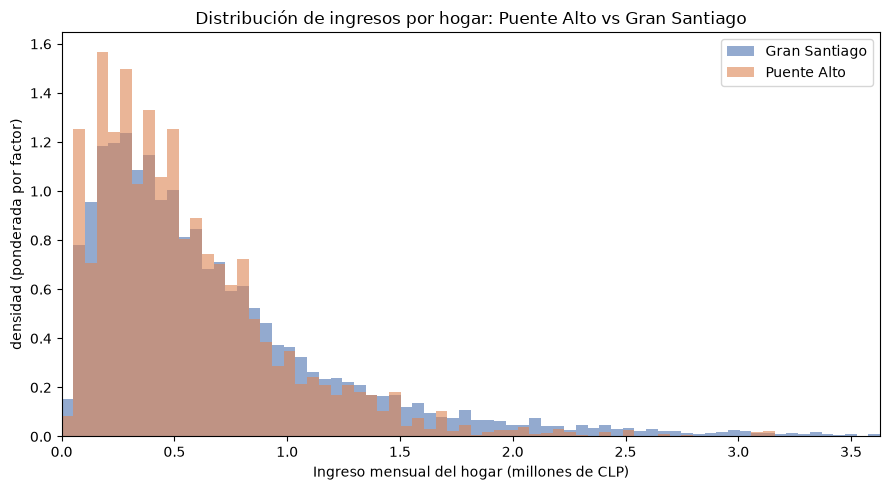

In [6]:
# Pregunta 5
# El ingreso por hogar vive en la tabla Hogares (una fila = un hogar).
# Cada hogar se pondera con su propio factor de expansión de hogar (Factor).

datos_pa = hogares[hogares["Comuna"] == MI_COMUNA].dropna(subset=["IngresoHogar"]).copy()
datos_gs = hogares.dropna(subset=["IngresoHogar"]).copy()

print("Hogares con ingreso válido | Puente Alto:", len(datos_pa),
      "| Gran Santiago:", len(datos_gs))

# Percentil 99 ponderado: se usa solo para limitar el eje del gráfico.
ordenados = datos_gs.sort_values("IngresoHogar")
posicion = np.searchsorted(ordenados["Factor"].cumsum(), 0.99 * ordenados["Factor"].sum())
p99 = ordenados.iloc[posicion]["IngresoHogar"] / 1e6
bins_comunes = np.linspace(0, p99, 71)
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(datos_gs["IngresoHogar"] / 1e6,bins=bins_comunes,density=True,weights=datos_gs["Factor"],alpha=0.6,
    color="#4C72B0",
    label="Gran Santiago"
)
ax.hist(datos_pa["IngresoHogar"] / 1e6,bins=bins_comunes,density=True,weights=datos_pa["Factor"],alpha=0.6,
    color="#DD8452",
    label="Puente Alto"
)
ax.set_xlabel("Ingreso mensual del hogar (millones de CLP)")
ax.set_ylabel("densidad (ponderada por factor)")
ax.set_title("Distribución de ingresos por hogar: Puente Alto vs Gran Santiago")
ax.set_xlim(0, p99)
ax.legend()
plt.tight_layout()
plt.show()

**Interpretación:** Se eligen dos histogramas de densidad superpuestos y ponderados por el factor de hogar. Normalizar a densidad permite comparar dos distribuciones con tamaños de muestra distintos. Se descartaron boxplots (ocultan la asimetría y colas), gráficos de barras con la media (colapsan la distribución a un número) y histogramas separados (dificultan la comparación). Ambas distribuciones son asimétricas a la derecha; Puente Alto se concentra más en ingresos bajos, con una cola derecha más corta que la del Gran Santiago. Para que se vea mejor dónde se concentra la mayoría de los hogares, el eje llega hasta el percentil 99 ponderado de la ciudad. Los ingresos superiores se mantienen en los cálculos; solo quedan fuera de la vista del gráfico.

### 6. La comuna de contraste (8 pts)

**Instrucciones**

Elijan una comuna con un perfil de movilidad distinto al de la suya y
justifiquen la elección con datos; una cifra basta.

Calculen el reparto modal ponderado de las tres unidades: su comuna, la de
contraste y el Gran Santiago. El modo de cada viaje está en `ViajesDifusion.csv`
(llave `Viaje`) y su catálogo en `tablas_parametros/ModoDifusion.csv`; un viaje
pertenece a la comuna de su origen y el peso es `FactorLaboralNormal`.

Muestren las tres unidades en una sola figura.

En la interpretación, lean el contraste entre las tres unidades.

                      PUENTE ALTO  VITACURA  Gran Santiago
Modo                                                      
Auto                         19.3      64.3           23.4
Bicicleta                     2.0       4.2            3.8
Bip!                         25.6      14.6           24.2
Bip! - Otros Privado          1.1       1.0            0.9
Bip! - Otros Publico          2.1       1.3            1.9
Caminata                     35.4      11.2           33.9
Otros                         7.6       1.3            6.9
Taxi                          0.6       1.5            1.6
Taxi Colectivo                6.3       0.6            3.4


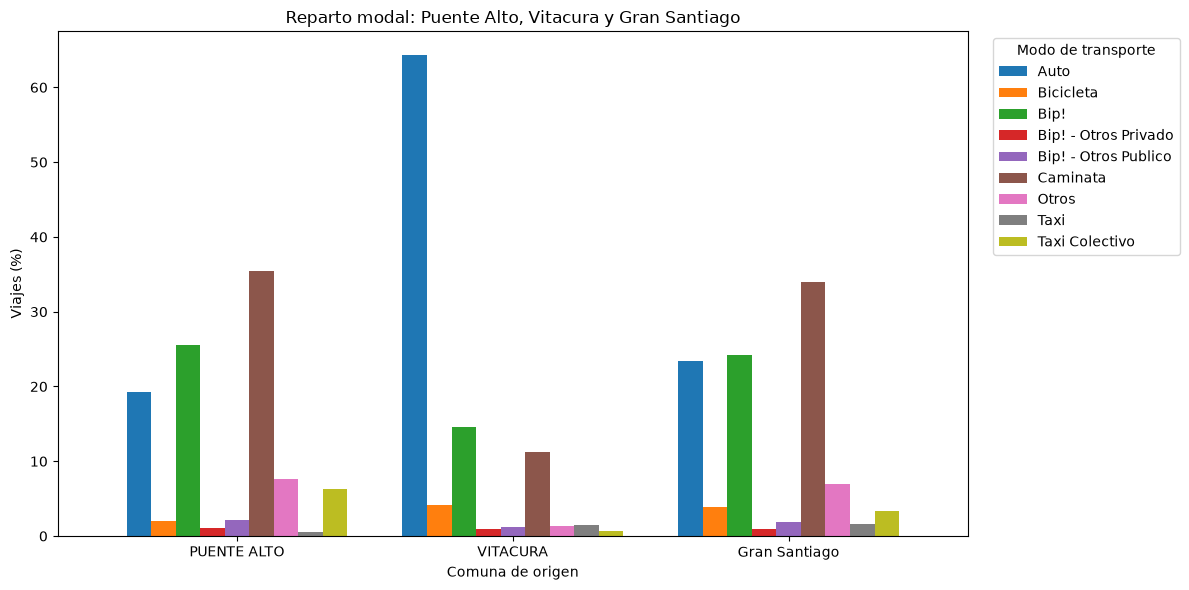

In [7]:
# Pregunta 6
# Vitacura se contrasta con Puente Alto por su mayor uso de auto.

viajes_dif = pd.read_csv(RUTA + "ViajesDifusion.csv", sep=";")
modo_dif = pd.read_csv(RUTA + "tablas_parametros/ModoDifusion.csv", sep=";")
comunas = pd.read_csv(RUTA + "tablas_parametros/Comuna.csv", sep=",")

# Se añade el modo a cada viaje, y los catálogos cambian los códigos por nombres.
viajes_dif = viajes_lab.merge(viajes_dif, on="Viaje", how="left", validate="one_to_one")
modo_dif = modo_dif.rename(columns={"ModoDifusion": "Modo"})
viajes_dif = viajes_dif.merge(modo_dif, left_on="ModoDifusion", right_on="ID", how="left")
viajes_dif = viajes_dif.merge(comunas, left_on="ComunaOrigen", right_on="Id", how="left")

repartos = {}
for nombre, datos in [(MI_COMUNA, viajes_dif[viajes_dif["Comuna"] == MI_COMUNA]),
                      (COMUNA_CONTRASTE, viajes_dif[viajes_dif["Comuna"] == COMUNA_CONTRASTE]),
                      ("Gran Santiago", viajes_dif)]:
    pesos = datos.groupby("Modo")["FactorLaboralNormal"].sum()
    repartos[nombre] = 100 * pesos / pesos.sum()

reparto_modal = pd.DataFrame(repartos).fillna(0)
print(reparto_modal.round(1).to_string())

# La leyenda muestra los modos; cada grupo de barras corresponde a una comuna.
ax = reparto_modal.T.plot.bar(figsize=(12, 6), width=0.8)
ax.set(xlabel="Comuna de origen", ylabel="Viajes (%)",
       title="Reparto modal: Puente Alto, Vitacura y Gran Santiago")
ax.legend(title="Modo de transporte", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretación:** Vitacura fue seleccionada como comuna de contraste debido a que representa un perfil socioeconómico mas alto que el de Puente Alto, permitiendo comparar dos comunas con diferentes.
Al observar los datos de movilidad, podemos observar que en Vitacura, el auto concentra el 64,3% de los viajes ponderados, mientras que en Puente Alto representa solo el 19,3% y en el Gran Santiago el 23,4% y por el contrario, Puente Alto presenta una mayor participación de la caminata, con un 35,4% frente al 11,2% de Vitacura, y de Bip!, con un 25,6% frente al 14,6%, pero si además se consideran las categorías combinadas con Bip!, estas representan aproximadamente un 28,8% de los viajes en Puente Alto y un 16,9% en Vitacura. 
En general, Puente Alto presenta un reparto más orientado a caminata y transporte público, mientras que Vitacura destaca por el predominio del automóvil. El Gran Santiago se encuentra más próximo al perfil de Puente Alto en varias categorías, aunque presenta valores intermedios dependiendo del modo analizado.

### 7. Ingreso y transporte público (8 pts)

**Instrucciones**

Para todas las comunas del Gran Santiago calculen dos series: el ingreso medio
ponderado de los hogares (`IngresoHogar` con `Factor`) y la proporción ponderada
de viajes en transporte público. Decidan qué modos de `ModoDifusion` cuentan
como transporte público y declárenlo; el peso de los viajes es
`FactorLaboralNormal`.

Grafiquen una serie contra la otra, con cada comuna como un punto, destacando la
suya y la de contraste. Calculen las correlaciones de Pearson y de Spearman
entre ambas series.

En la interpretación: ¿qué indica la diferencia entre los dos coeficientes?
¿Qué comunas se apartan del patrón general, y dónde queda la suya?


Pearson: 0.11
Spearman: 0.26


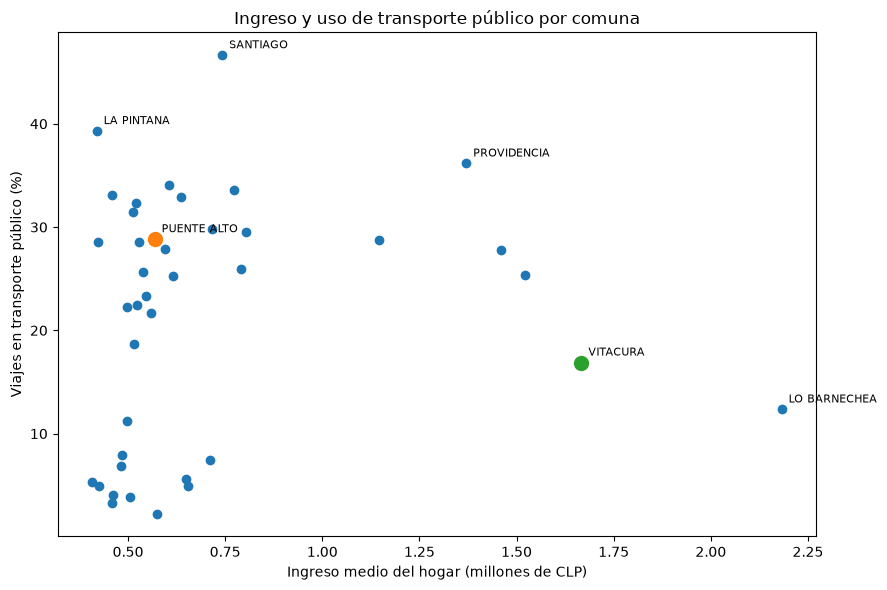

In [8]:
# Pregunta 7
# Ingreso y transporte público

#Ingreso medio ponderado por comuna

ingresos = hogares.dropna(subset=["Comuna", "IngresoHogar", "Factor"]).copy()

# Ingreso multiplicado por el factor de cada hogar

ingresos["IngresoPonderado"] = (ingresos["IngresoHogar"] * ingresos["Factor"])
ingreso_comuna = ingresos.groupby("Comuna").agg(IngresoPonderado=("IngresoPonderado", "sum"), FactorTotal=("Factor", "sum"))
ingreso_comuna["IngresoMedio"] = (ingreso_comuna["IngresoPonderado"]/ ingreso_comuna["FactorTotal"])

# Proporción de transporte publico por comuna

viajes_tp = viajes_dif.dropna(subset=["Comuna", "Modo", "FactorLaboralNormal"]).copy()

# Consideramos transporte publico todos los modos que comienzan con "Bip!"
viajes_tp["EsTP"] = viajes_tp["Modo"].str.startswith("Bip!")

# Si es transporte publico conserva su factor y si no lo es vale 0
viajes_tp["FactorTP"] = (viajes_tp["FactorLaboralNormal"]* viajes_tp["EsTP"])

tp_comuna = viajes_tp.groupby("Comuna").agg(FactorTP=("FactorTP", "sum"),FactorTotal=("FactorLaboralNormal", "sum"))
tp_comuna["PropTP"] = (tp_comuna["FactorTP"]/ tp_comuna["FactorTotal"]* 100)

# Juntar ambos resultados por comuna
tabla7 = ingreso_comuna[["IngresoMedio"]].merge(tp_comuna[["PropTP"]],left_index=True,right_index=True,how="inner")

# Calculamos correlaciones de Pearson y Spearman

pearson = tabla7["IngresoMedio"].corr(tabla7["PropTP"])
spearman = tabla7["IngresoMedio"].corr(tabla7["PropTP"], method="spearman")

print(f"\nPearson: {pearson:.2f}")
print(f"Spearman: {spearman:.2f}")

# Gráfico

fig, ax = plt.subplots(figsize=(9, 6))

ax.scatter(tabla7["IngresoMedio"] / 1e6,tabla7["PropTP"])

comunas_con_nombre = [
    "PUENTE ALTO",
    "VITACURA",
    "SANTIAGO",
    "LA PINTANA",
    "PROVIDENCIA",
    "LO BARNECHEA"
]

for comuna in comunas_con_nombre:
    x = tabla7.loc[comuna, "IngresoMedio"] / 1e6
    y = tabla7.loc[comuna, "PropTP"]

    ax.annotate(
        comuna,
        (x, y),
        xytext=(5, 5),
        textcoords="offset points",
        fontsize=8
    )

for comuna in [MI_COMUNA, COMUNA_CONTRASTE]:
    x = tabla7.loc[comuna, "IngresoMedio"] / 1e6
    y = tabla7.loc[comuna, "PropTP"]

    ax.scatter(x, y, s=100)

ax.set_xlabel("Ingreso medio del hogar (millones de CLP)")
ax.set_ylabel("Viajes en transporte público (%)")
ax.set_title("Ingreso y uso de transporte público por comuna")

plt.tight_layout()
plt.show()

**Interpretación:** Se consideraron como transporte público los modos de ModoDifusion en los que el nombre comienzara con "Bip!", incluyendo sus combinaciones con otros modos.
La correlación de Pearson entre el ingreso medio de los hogares y la proporción de viajes en transporte público fue de 0,08, mientras que la correlación de Spearman fue de 0,23. Ambos valores son bajos, por lo que los datos no muestran una asociación fuerte entre ambas variables a nivel comunal. El hecho de que Spearman sea algo mayor que Pearson sugiere una relación monotónica ligeramente más marcada que la relación lineal, aunque esta sigue siendo débil. 
El gráfico muestra una gran dispersión entre comunas con niveles de ingreso similares. Entre las que más se apartan del patrón general se encuentran Santiago, con la mayor proporción de transporte público La Pintana, que combina un ingreso relativamente bajo con una alta participación del transporte público, Providencia, que presenta simultáneamente un ingreso alto y una elevada proporción de transporte público; y Lo Barnechea, que presenta el ingreso medio más alto y una baja participación del transporte público. Vitacura también se encuentra separada de la mayor concentración de comunas debido a su alto ingreso y presenta cerca de un 17% de viajes en transporte público. Puente Alto, en cambio, se encuentra dentro de la concentración principal, con un ingreso medio cercano a $0,57 millones y alrededor de un 29% de viajes en transporte público.

### 8. Un hallazgo propio (6 pts)

**Instrucciones**

Agreguen un gráfico a elección que muestre algo del retrato que los ítems
anteriores no capturan, ponderado como todo lo demás. Se evalúa que el hallazgo
no sea trivial: que no repita lo ya visto ni muestre algo obvio.

En la interpretación, escriban la lectura del hallazgo en dos o tres líneas.

                              Puente Alto  Gran Santiago
Proposito                                               
Al estudio                           14.3            9.4
Al trabajo                           20.5           16.1
Buscar o Dejar a alguien              5.0            4.6
Buscar o dejar algo                   0.6            0.5
Comer o Tomar algo                    0.1            0.8
De compras                            7.8            8.7
De salud                              1.7            2.1
Otra actividad (especifique)          1.1            1.5
Por estudio                           0.3            1.2
Por trabajo                           1.2            1.6
Recreación                            1.2            1.7
Trámites                              4.0            3.7
Visitar a alguien                     2.2            2.3
volver a casa                        39.9           45.8


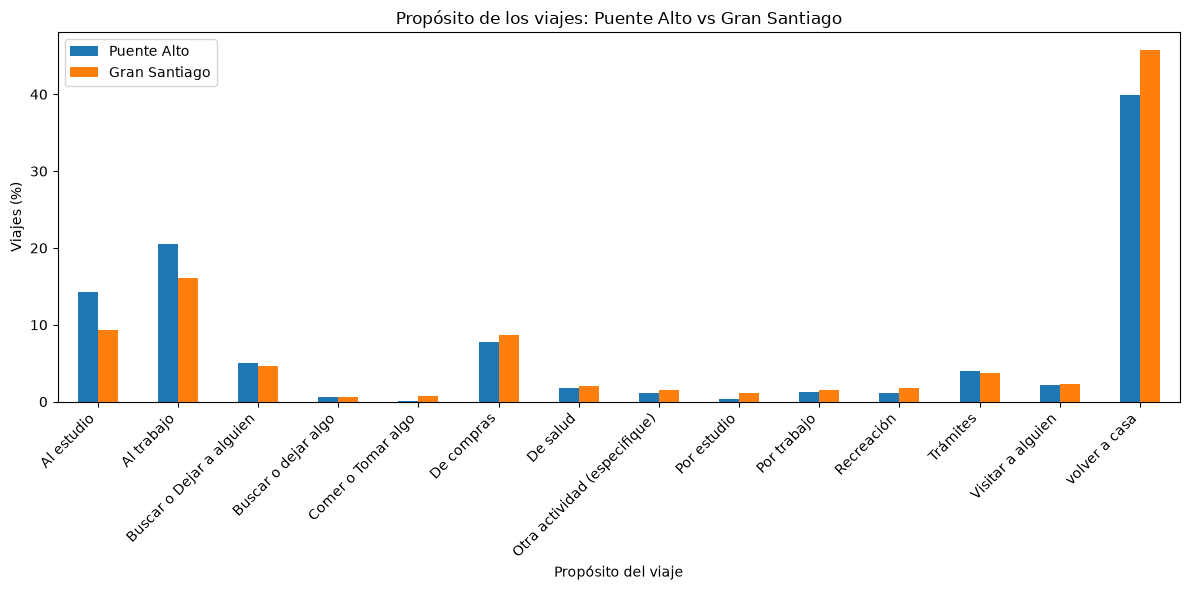

In [9]:
# Pregunta 8
# Propósito de los viajes: Puente Alto vs Gran Santiago

proposito = pd.read_csv(RUTA + "tablas_parametros/Proposito.csv",sep=";")

# Agregamos el nombre de la comuna de origen
viajes_prop = viajes_lab.merge(comunas,left_on="ComunaOrigen",right_on="Id",how="left")

# Agregamos el nombre del propósito
viajes_prop = viajes_prop.merge(proposito,left_on="Proposito",right_on="Id",how="left",suffixes=("_codigo", ""))

# Nos quedamos con datos válidos
viajes_prop = viajes_prop.dropna(subset=["Comuna", "Proposito", "FactorLaboralNormal"])

pa = viajes_prop[viajes_prop["Comuna"] == MI_COMUNA]

prop_pa = pa.groupby("Proposito")["FactorLaboralNormal"].sum()
prop_pa = prop_pa / prop_pa.sum() * 100

prop_gs = viajes_prop.groupby("Proposito")["FactorLaboralNormal"].sum()
prop_gs = prop_gs / prop_gs.sum() * 100

# Juntamos ambas series
tabla8 = pd.DataFrame({"Puente Alto": prop_pa,"Gran Santiago": prop_gs}).fillna(0)

print(tabla8.round(1))

# Gráfico
ax = tabla8.plot.bar(figsize=(12, 6))

ax.set_xlabel("Propósito del viaje")
ax.set_ylabel("Viajes (%)")
ax.set_title("Propósito de los viajes: Puente Alto vs Gran Santiago")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

**Interpretación:** Puente Alto presenta una mayor proporción de viajes cuyo propósito es ir al trabajo y al estudio que el Gran Santiago. En particular, los viajes al trabajo representan aproximadamente un 20% en Puente Alto frente a un 16% en la ciudad, mientras que los viajes al estudio alcanzan cerca de un 14% frente a un 9%. En cambio, la proporción de viajes de regreso al hogar es menor en Puente Alto.

## Parte 3. Decisiones sobre los datos (25 puntos)

### 9. Los que faltan (8 pts)

**Instrucciones**

Identifiquen los datos faltantes que afectan su retrato: al menos
`IngresoHogar`, los factores de expansión, `TiempoViaje` y las coordenadas.
Determinen si esos faltantes siguen algún patrón (por ejemplo, si se concentran
en algún grupo o comuna) o si pueden tratarse como ausencias sin estructura, y
muestren la evidencia. Recuerden lo visto en clase: un `NaN` en los factores no
es un error, significa que esa persona no pertenece a ese universo.

Declaren qué decidieron hacer con los faltantes y recalculen una de las cifras
de su retrato con la decisión contraria, para mostrar cuánto cambia.

In [10]:
# Pregunta 9
# Datos faltantes

# Cantidad de faltantes

print("---- HOGARES ----")
print("IngresoHogar:", hogares["IngresoHogar"].isna().sum())
print("Factor:", hogares["Factor"].isna().sum())

print("\n---- PERSONAS ----")
print( "Factor_LaboralNormal:",personas["Factor_LaboralNormal"].isna().sum())

print("\n---- VIAJES ----")
print("FactorLaboralNormal:",viajes["FactorLaboralNormal"].isna().sum())
print("TiempoViaje:", viajes["TiempoViaje"].isna().sum())
print("OrigenCoordX:", viajes["OrigenCoordX"].isna().sum())
print("OrigenCoordY:", viajes["OrigenCoordY"].isna().sum())
print("DestinoCoordX:", viajes["DestinoCoordX"].isna().sum())
print("DestinoCoordY:", viajes["DestinoCoordY"].isna().sum())


# Patrón de faltantes por comuna

viajes_faltantes = viajes.merge(comunas[["Id", "Comuna"]],left_on="ComunaOrigen",right_on="Id",how="left")
viajes_faltantes["FaltaTiempo"] = (viajes_faltantes["TiempoViaje"].isna())

viajes_faltantes["FaltaCoordenada"] = (
    viajes_faltantes[
        [
            "OrigenCoordX",
            "OrigenCoordY",
            "DestinoCoordX",
            "DestinoCoordY"
        ]
    ]
    .isna()
    .any(axis=1)
)

patron_faltantes = (viajes_faltantes.groupby("Comuna")[["FaltaTiempo", "FaltaCoordenada"]].mean()* 100)

print("\nPorcentaje de faltantes por comuna:")
print(patron_faltantes.sort_values("FaltaCoordenada", ascending=False).round(2))


# Faltantes de ingreso por comuna

hogares_faltantes = hogares.copy()
hogares_faltantes["FaltaIngreso"] = (hogares_faltantes["IngresoHogar"].isna())

faltantes_ingreso = (hogares_faltantes.groupby("Comuna")["FaltaIngreso"].mean()* 100)

print("\nFaltantes de ingreso por comuna:")
print(faltantes_ingreso.sort_values(ascending=False).round(2))

# Sensibilidad a otra decisión sobre TiempoViaje

duracion = viajes_lab[["TiempoViaje", "FactorLaboralNormal"]].copy()

# Decisión usada: excluir los viajes sin duración
sin_faltantes = duracion.dropna(subset=["TiempoViaje"])

media_sin_faltantes = np.average(sin_faltantes["TiempoViaje"],weights=sin_faltantes["FactorLaboralNormal"])

# Decisión contraria: imputar los faltantes con la mediana
mediana_tiempo = duracion["TiempoViaje"].median()

con_imputacion = duracion.copy()
con_imputacion["TiempoViaje"] = (con_imputacion["TiempoViaje"].fillna(mediana_tiempo))
media_con_imputacion = np.average(con_imputacion["TiempoViaje"],weights=con_imputacion["FactorLaboralNormal"])

print("\nComparación de decisiones:")
print(f"Media excluyendo faltantes: "f"{media_sin_faltantes:.2f} min")
print(f"Media imputando con la mediana: " f"{media_con_imputacion:.2f} min")
print(f"Diferencia: "f"{media_con_imputacion - media_sin_faltantes:.2f} min")

---- HOGARES ----
IngresoHogar: 0
Factor: 0

---- PERSONAS ----
Factor_LaboralNormal: 22728

---- VIAJES ----
FactorLaboralNormal: 34771
TiempoViaje: 278
OrigenCoordX: 19741
OrigenCoordY: 19741
DestinoCoordX: 19741
DestinoCoordY: 19741

Porcentaje de faltantes por comuna:
                     FaltaTiempo  FaltaCoordenada
Comuna                                           
LAMPA                       0.17            42.97
BUIN                        0.08            33.73
COLINA                      0.00            33.26
SAN BERNARDO                0.15            28.68
EL BOSQUE                   0.09            28.15
LO ESPEJO                   0.00            28.02
LA GRANJA                   0.00            27.99
RENCA                       0.24            26.58
PEDRO AGUIRRE CERDA         0.06            26.37
CERRO NAVIA                 0.00            25.99
TALAGANTE                   0.20            25.55
PUDAHUEL                    0.03            25.42
EL MONTE                   

**Interpretación:** IngresoHogar y el factor de expansión de hogares no presentan valores faltantes. Los NaN de los factores laborales de personas y viajes no se consideran errores, ya que indican observaciones que no pertenecen al universo de día laboral normal. En TiempoViaje los faltantes son poco frecuentes: en Puente Alto representan solo un 0,18%, aunque algunas comunas como Conchalí (4,36%) e Independencia (1,92%) presentan proporciones mayores. En cambio, las coordenadas muestran un patrón más marcado por comuna: Puente Alto tiene un 20,05% de viajes con alguna coordenada faltante, mientras que la proporción varía desde 4,58% en Vitacura hasta 42,97% en Lampa.
Para el análisis se decidió excluir los valores faltantes únicamente de los cálculos que requieren la variable correspondiente, sin imputarlos artificialmente. Como comprobación, al imputar los TiempoViaje faltantes con la mediana, la media ponderada cambia de 34,68 a 34,66 minutos, una diferencia de apenas 0,01 minutos, por lo que la decisión tiene un efecto despreciable sobre esta cifra.

### 10. Los extremos (8 pts)

**Instrucciones**

Busquen valores extremos o sospechosos en las duraciones (`TiempoViaje`) y en
las distancias de los viajes con origen en su comuna. La distancia está en
`DistanciaViaje.csv`, con llave `Viaje` y expresada en metros.

Cuantifíquenlos con algún criterio explícito: la regla de Tukey del boxplot, el
criterio de desviaciones estándar respecto de la media (por ejemplo, tres
sigmas), u otro que conozcan y justifiquen.

Investíguenlos: ¿son errores de registro o viajes reales posibles? Declaren la
decisión que tomaron (mantener, corregir o excluir) y muestren su efecto sobre
las medidas que reportaron, por ejemplo comparando la media y la mediana con y
sin ellos.

In [11]:
# Pregunta 10
# Valores extremos en duración y distancia de los viajes de Puente Alto

distancias = pd.read_csv(RUTA + "DistanciaViaje.csv", sep=";", decimal=",")

# Viajes con origen en Puente Alto
viajes_pa = viajes_lab.merge(comunas[["Id", "Comuna"]], left_on="ComunaOrigen", right_on="Id", how="left")
viajes_pa = viajes_pa[viajes_pa["Comuna"] == MI_COMUNA]

# Agregamos la distancia mediante la llave Viaje
viajes_pa = viajes_pa.merge(distancias[["Viaje", "DistEuclidiana"]], on="Viaje", how="left")
comunas_destino = comunas.rename(columns={"Id": "ComunaDestino", "Comuna": "NombreDestino"})
viajes_pa = viajes_pa.merge(comunas_destino[["ComunaDestino", "NombreDestino"]], on="ComunaDestino", how="left")

#Función para obtener límites de Tukey

def tukey(serie):
    q1 = serie.quantile(0.25)
    q3 = serie.quantile(0.75)
    iqr = q3 - q1
    limite_bajo = q1 - 1.5 * iqr
    limite_alto = q3 + 1.5 * iqr
    return limite_bajo, limite_alto


# Valores extremos de TiempoViaje

tiempo = viajes_pa[viajes_pa["TiempoViaje"] > 0]["TiempoViaje"].dropna()
limite_tiempo_bajo, limite_tiempo_alto =tukey(tiempo)
extremos_tiempo = viajes_pa[(viajes_pa["TiempoViaje"] < limite_tiempo_bajo) | (viajes_pa["TiempoViaje"] > limite_tiempo_alto)]

print("---- TIEMPO DE VIAJE ----")
print(f"Límite inferior: {limite_tiempo_bajo:.1f} min")
print(f"Límite superior: {limite_tiempo_alto:.1f} min")
print(f"Cantidad de extremos: {len(extremos_tiempo)}")
print(f"Máximo registrado: {tiempo.max():.1f} min")
print("\nViajes con mayor duración:")
print(viajes_pa[["Viaje", "TiempoViaje", "DistEuclidiana", "NombreDestino"]].sort_values("TiempoViaje", ascending=False).head(10))

# Valores extremos de distancia

distancia = viajes_pa[viajes_pa["DistEuclidiana"] > 0]["DistEuclidiana"].dropna()
limite_dist_bajo, limite_dist_alto = tukey(distancia)
extremos_dist = viajes_pa[(viajes_pa["DistEuclidiana"] > 0) & ((viajes_pa["DistEuclidiana"] < limite_dist_bajo) | (viajes_pa["DistEuclidiana"] > limite_dist_alto))]

print("\n---- DISTANCIA ----")
print(f"Límite inferior: {limite_dist_bajo:.0f} m")
print(f"Límite superior: {limite_dist_alto:.0f} m")
print(f"Cantidad de extremos: {len(extremos_dist)}")
print(f"Máxima registrada: {distancia.max() / 1000:.1f} km")
print("\nViajes con mayor distancia:")
print(viajes_pa[["Viaje", "TiempoViaje", "DistEuclidiana", "NombreDestino"]].sort_values("DistEuclidiana", ascending=False).head(10))

# Efecto de excluir los extremos

# Datos originales válidos
tiempo_valido = viajes_pa[(viajes_pa["TiempoViaje"] > 0) & viajes_pa["FactorLaboralNormal"].notna()].copy()
# Dejamos solo valores dentro de los límites de Tukey

tiempo_sin_extremos = tiempo_valido[(tiempo_valido["TiempoViaje"] >= limite_tiempo_bajo) & (tiempo_valido["TiempoViaje"] <= limite_tiempo_alto)]

# Media ponderada de duración

media_original = np.average(tiempo_valido["TiempoViaje"], weights=tiempo_valido["FactorLaboralNormal"])
media_sin_extremos = np.average(tiempo_sin_extremos["TiempoViaje"], weights=tiempo_sin_extremos["FactorLaboralNormal"])

# Mediana ponderada de duración
mediana_original = weighted_median(tiempo_valido["TiempoViaje"].values, tiempo_valido["FactorLaboralNormal"].values)
mediana_sin_extremos = weighted_median(tiempo_sin_extremos["TiempoViaje"].values, tiempo_sin_extremos["FactorLaboralNormal"].values)

print("\n---- EFECTO SOBRE LA DURACIÓN ----")
print(f"Media original: {media_original:.2f} min")
print(f"Media sin extremos: {media_sin_extremos:.2f} min")
print(f"Mediana original: {mediana_original:.2f} min")
print(f"Mediana sin extremos: {mediana_sin_extremos:.2f} min")

---- TIEMPO DE VIAJE ----
Límite inferior: -65.0 min
Límite superior: 135.0 min
Cantidad de extremos: 65
Máximo registrado: 720.0 min

Viajes con mayor duración:
           Viaje  TiempoViaje  DistEuclidiana NombreDestino
1656  2239100201        720.0              -1           NaN
3331  2298430101        540.0           18827    LAS CONDES
1898  2248310402        270.0            2727   PUENTE ALTO
1147  2219310201        250.0              -1           NaN
2752  2277110101        240.0           68900           NaN
19    1315010202        230.0            4727    LA FLORIDA
2074  2255210101        215.0           65342           NaN
3849  2323220102        215.0            1667   PUENTE ALTO
24    1320210202        200.0            7414    LA FLORIDA
23    1320210102        200.0            7407    LA FLORIDA

---- DISTANCIA ----
Límite inferior: -10334 m
Límite superior: 19054 m
Cantidad de extremos: 360
Máxima registrada: 68.9 km

Viajes con mayor distancia:
           Viaje  Tiempo

**Interpretación:** La regla de Tukey identificó como atípicos los viajes de más de 135 minutos y las distancias superiores a 19,1 km, encontrándose 65 y 360 casos respectivamente, ademas las distancias más altas parecen posibles, ya que varios viajes corresponden a destinos alejados como Melipilla, Colina y Lampa, por lo que se decidió mantenerlas. En cambio, algunas duraciones son sospechosas, como viajes de 720 y 540 minutos o viajes de varias horas para distancias muy cortas. Al excluir los valores extremos de duración, la media ponderada disminuye de 34,45 a 32,68 minutos, mientras que la mediana se mantiene en 20 minutos, mostrando que esta última es menos sensible a los valores extremos.

### 11. Una transformación (9 pts)

**Instrucciones**

Apliquen una transformación justificada a una variable de su retrato, por
ejemplo el logaritmo al ingreso o a la duración.

Muestren el efecto con un gráfico del antes y el después.

En la interpretación, expliquen cómo cambia la forma de la distribución y qué
medidas se vuelven más o menos informativas después de la transformación.

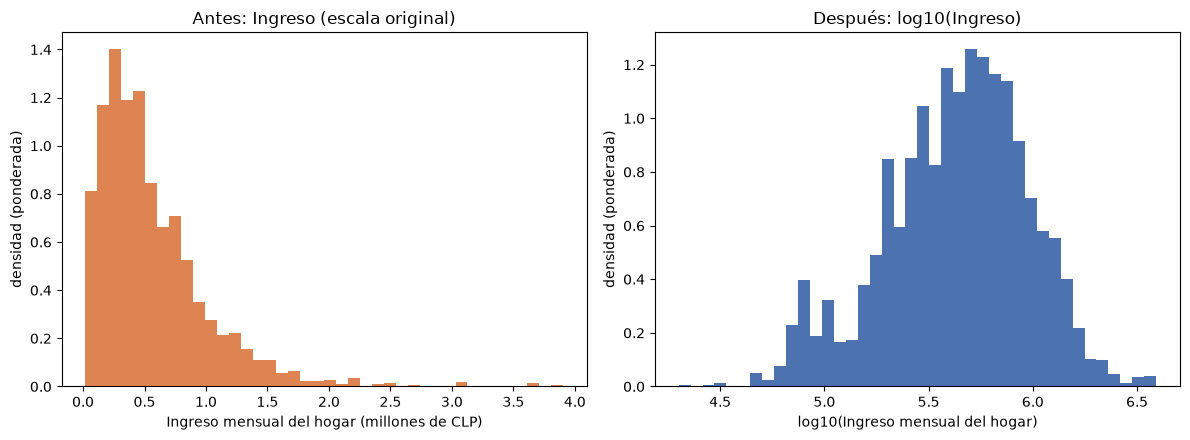

Media de log10(ingreso): 5.630   -> 10^ = 426,859 CLP
Mediana de log10(ingreso): 5.663
En escala log, media y mediana quedan cercanas: la distribución se vuelve casi simétrica.


In [12]:
# Pregunta 11
# Transformación logarítmica del ingreso de los hogares de Puente Alto
# (la distribución es asimétrica a la derecha, visto en Q3 y Q5).

hogares_ing = hogares[hogares["Comuna"] == MI_COMUNA].dropna(subset=["IngresoHogar", "Factor"]).copy()
hogares_ing["LogIngreso"] = np.log10(hogares_ing["IngresoHogar"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Antes: ingreso en su escala original
axes[0].hist(hogares_ing["IngresoHogar"] / 1e6, bins=40, density=True,
             weights=hogares_ing["Factor"], color="#DD8452")
axes[0].set_xlabel("Ingreso mensual del hogar (millones de CLP)")
axes[0].set_ylabel("densidad (ponderada)")
axes[0].set_title("Antes: Ingreso (escala original)")

# Después: log10 del ingreso
axes[1].hist(hogares_ing["LogIngreso"], bins=40, density=True,
             weights=hogares_ing["Factor"], color="#4C72B0")
axes[1].set_xlabel("log10(Ingreso mensual del hogar)")
axes[1].set_ylabel("densidad (ponderada)")
axes[1].set_title("Después: log10(Ingreso)")

plt.tight_layout()
plt.show()

# Medidas en escala logarítmica (ponderadas por Factor)
media_log = weighted_mean(hogares_ing["LogIngreso"].values, hogares_ing["Factor"].values)
mediana_log = weighted_median(hogares_ing["LogIngreso"].values, hogares_ing["Factor"].values)

print(f"Media de log10(ingreso): {media_log:.3f}   -> 10^ = {10**media_log:,.0f} CLP")
print(f"Mediana de log10(ingreso): {mediana_log:.3f}")
print("En escala log, media y mediana quedan cercanas: la distribución se vuelve casi simétrica.")

**Interpretación:** En la escala original, el ingreso de los hogares es fuertemente asimétrico a la derecha (Q3 y Q5): la media ponderada (568.516 CLP) supera claramente a la mediana (460.000 CLP) y a la media truncada (503.267 CLP), porque la cola de ingresos altos tira de la media. Al aplicar log10, esa cola se comprime y la distribución se vuelve casi simétrica; un reflejo de ello es que la media y la mediana evaluadas en la escala logarítmica quedan muy próximas. En esta escala, la media vuelve a ser informativa: 10^media corresponde a la media geométrica del ingreso, un valor cercano al ingreso típico y mucho menos sensible a los extremos que la media aritmética original. Así, antes de la transformación conviene reportar la mediana o la media truncada; después de ella, la media en escala log es una medida estable y comparable entre comunas o grupos.

## Parte 4. Síntesis (20 puntos)

### 12. El retrato (8 pts)

**Instrucciones**

- Escriban aquí "El retrato de [su comuna]" en **máximo 10 líneas**, integrando
  los hallazgos numéricos y gráficos de toda la tarea.
- Debe poder leerse sola, sin el resto del notebook: con cifras concretas, no
  con referencias a "el gráfico anterior".

**El retrato de Puente Alto**

Puente Alto es la comuna más habitada del Gran Santiago: sus 3.378 personas
(1.662 hogares) encuestadas representan 563.461 personas y 165.759 hogares. Es
una población joven (mediana de edad 33 años) y levemente femenina (51,4%). El
ingreso del hogar es bajo y algo desigual: media de 568.516 CLP, mediana de
460.000 CLP y media truncada de 503.267 CLP, muy por debajo de la ciudad
(729.898 CLP). El parque vehicular es más antiguo (mediana 6 años vs. 5) y con
menos sello verde (18,8% vs. 25,1%). La movilidad depende de la caminata
(35,4%) y de Red/Bip! (25,6%), y el auto solo tiene el 19,3% de los viajes
(64,3% en Vitacura). Sus viajes se orientan más al trabajo (20,5%) y al
estudio (14,3%) que en el resto de la ciudad.

### 13. ¿De quién hablan sus números? (6 pts)

**Instrucciones**

- ¿Sus cifras hablan de la muestra, de su comuna, de la ciudad? ¿De qué días y
  temporada, dado el universo que declararon?
- ¿Qué personas o viajes podrían estar quedando fuera del retrato? Piensen en
  quién responde una encuesta presencial de 2012 y quién no.

**Respuesta:** Las cifras del retrato hablan de la población residente en
viviendas particulares de Puente Alto (y de las comunas del Gran Santiago),
estimada con los factores de expansión — no de la muestra cruda. El universo
declarado es el día laboral de temporada normal, así que no representan
sábados, domingos ni la temporada estival. Quedan fuera quienes no están en el
hogar durante la visita de un día laboral (quienes trabajan o estudian fuera y
no dejan informante), los hogares desocupados o que rechazan participar, las
personas sin vivienda fija y quienes viven en instituciones (hospitales,
cárceles, residencias). El factor compensa por diseño parte de esas ausencias,
pero subestima a los no localizables en la vivienda en día laboral. Además, el
análisis excluyó viajes con datos faltantes (un 20,05% de los viajes de Puente
Alto sin coordenadas) y los de duración extrema, que también quedan fuera del
retrato.

### 14. Una hipótesis para más adelante (6 pts)

**Instrucciones**

- Formulen una hipótesis **verificable** que su exploración sugiere pero no
  demuestra (por ejemplo, sobre la relación entre dos variables de su comuna).
- Se evalúa que sea precisa, comprobable y motivada por sus datos. 

**Hipótesis:** Dentro de Puente Alto, a mayor ingreso del hogar, menor es la
proporción de viajes de sus integrantes en transporte público (Red/Bip!) y
mayor la participación del auto. La motiva el contraste comunal de Q6:
Vitacura, de alto ingreso, concentra el 64,3% de sus viajes en auto y el 16,9%
en Bip!, mientras Puente Alto, de bajo ingreso, usa Bip! en un 28,8% y el auto
en un 19,3%. Es verificable cruzando hogares-personas-viajes por la llave
Hogar y comparando el reparto modal por decil de ingreso del hogar,
controlando por acceso a vehículo.

## Declaración de uso de IA generativa

Se utilizó opencode (modelo big-pickle) para asistir en la generación del código de análisis de datos, la elaboración de interpretaciones y la revisión de la estructura del notebook.

## Antes de entregar

- [ ] El notebook corre de principio a fin sin errores.
- [ ] `MI_COMUNA` y `COMUNA_CONTRASTE` están definidas.
- [ ] Toda cifra poblacional está ponderada y su universo está declarado.
- [ ] Todos los gráficos tienen título y ejes rotulados con unidades.
- [ ] Todas las celdas de "Interpretación" están completas.
- [ ] El archivo se llama `tarea1_apellido1_apellido2.ipynb`.
- [ ] La declaración de uso de IA está completa.